# Renders

This document contains code that can render some videos and visualizations of our final SLEAP model for the diet data using powershell commands to sleap io

We have this batch script from our old testing. We can just deconstruct it accordingly

```bash
PRED=../predictions/LD_rep6_Camera0_20250924_124210_0-215999.predictions.slp
OUT=../renders/LD_rep6_Camera0_20250924_124210_0-215999_frames_8000-10000.nodes.viz.mp4
mkdir -p ../renders

echo ""
echo "==== SIO render ===="
# Draft is a good balance; use preview for quick checks, final for publication-ish output.
sio render "$PRED" -o "$OUT" \
  --preset final \
  --start 8000 --end 10000 \
  --color-by node \
  --palette rainbow \
  --no-edges \
  --marker-size 3 \
  --x264-preset slow \
  --crf 10
echo "===================="

echo "Rendered: $OUT"
```

Note that we will need to grab the predictions from our SleapInferencePipeline we can just grab these and put them into our current working directory for now.
Additionally, we need the video in question. We can just pass the relative path since it's currently in the same parent directory as our project folder here.

In [2]:
# lets config our current project envi
from pathlib import Path
# Output directory (renders/output/)

# Files in current directory
PRED_FILE = Path("./LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp")

# Relative path to source video in parent directory
VIDEO_FILE = Path("../videos/LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4")

# Destination video file
OUT_FILE = Path("./output/LD_rep6_Camera0_20250924_124210_0-215999_frames_8000-10000.nodes.viz.mp4")

print(f"Predictions found: {PRED_FILE.is_file()} -> {PRED_FILE.name}")
print(f"Source video found: {VIDEO_FILE.is_file()} -> {VIDEO_FILE.name}")
print(f"Output path:       {OUT_FILE}")

Predictions found: True -> LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp
Source video found: True -> LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4
Output path:       output\LD_rep6_Camera0_20250924_124210_0-215999_frames_8000-10000.nodes.viz.mp4


In [ ]:
import sleap_io as sio
from pathlib import Path
from IPython.display import Video, display

# 1. Setup paths above


# 2. Load predictions and relink video file
print("Loading predictions dataset...")
labels = sio.load_slp(str(PRED_FILE.resolve()))

if labels.videos:
    labels.videos[0].filename = str(VIDEO_FILE.resolve())

# 3. Render video using sleap_io Python API
print(f"Rendering frames 8000 to 10000 to {OUT_FILE.name}...")

sio.render_video(
    source=labels,
    save_path=OUT_FILE,
    start=8000,
    end=10001,              # End frame is exclusive (10001 captures frame 10000)
    preset="final",
    color_by="node",
    palette="rainbow",
    show_nodes=True,
    show_edges=False,        # Matches --no-edges
    marker_size=3.0,
    
    # Encoding Options
    x264_preset="slow",
    crf=2,
    show_progress=True
)

print(f"\nRender finished -> {OUT_FILE}")

# 4. Preview inline in Jupyter
#if OUT_FILE.exists():
#    display(Video(str(OUT_FILE), embed=True, width=720, html_attributes="controls loop"))

Loading predictions dataset...
Rendering frames 8000 to 10000 with trails to LD_rep6_Camera0_20250924_124210_0-215999_frames_8000-10000.nodes.viz.mp4...


Rendering: 100%|██████████| 2001/2001 [01:49<00:00, 18.26frame/s]



Render finished -> output\LD_rep6_Camera0_20250924_124210_0-215999_frames_8000-10000.nodes.viz.mp4


## Render video with crop.

In [ ]:
import sleap_io as sio
from pathlib import Path
from IPython.display import Video, display

# 1. Directory and file paths
PRED_FILE = Path("./LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp")
VIDEO_FILE = Path("../videos/LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4")

# 2. Clip and crop settings from batch script
START = 67740
END = 70440
CROP = (1180, 852, 1730, 1422)  # (x1, y1, x2, y2) pixel bounding box
TAG = f"roi_x1180_y852_w559_h570_f{START}-{END}"

OUT_FILE = Path(f"output/LD_rep6_Camera0_20250924_124210_0-215999.{TAG}.mp4")

# 3. Load predictions dataset & relink video
print(f"Loading predictions from: {PRED_FILE.name}...")
labels = sio.load_slp(str(PRED_FILE.resolve()))

if labels.videos:
    labels.videos[0].filename = str(VIDEO_FILE.resolve())

# 4. Render video using identical bash parameters
print(f"Rendering frames {START} to {END} (CRF 5, preset slow)...")
sio.render_video(
    source=labels,
    save_path=OUT_FILE,
    start=START,
    end=END,
    crop=CROP,
    preset="final",
    color_by="node",
    palette="rainbow",
    show_nodes=True,
    show_edges=False,
    marker_size=3.0,
    alpha=0.5,
    crf=2,
    x264_preset="slow",
    show_progress=True
)

print(f"\nRender complete: {OUT_FILE}")

# 5. Inline playback
#if OUT_FILE.exists():
#    display(Video(str(OUT_FILE), embed=True, width=720, html_attributes="controls loop"))

Loading predictions from: LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp...
Rendering frames 67740 to 70440 (CRF 5, preset slow)...


Rendering: 100%|██████████| 2700/2700 [00:35<00:00, 76.25frame/s]



Render complete: output\LD_rep6_Camera0_20250924_124210_0-215999.roi_x1180_y852_w559_h570_f67740-70440.viz.highqualityrender.mp4


## Renders only showing the target node i.e. abdomen

In [6]:
import numpy as np
import sleap_io as sio
from pathlib import Path
from IPython.display import Video, display


PRED_FILE = Path("./LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp")
VIDEO_FILE = Path("../videos/LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4")
OUT_FILE = Path("output/LD_rep6_Camera0_frames_8000-10000.abdomen_only.mp4")

# 2. Load predictions
labels = sio.load_slp(str(PRED_FILE.resolve()))
if labels.videos:
    labels.videos[0].filename = str(VIDEO_FILE.resolve())

# 3. Locate target node index in skeleton
TARGET_NODE = "ab"
skeleton = labels.skeletons[0]
node_names = [n.name.lower() for n in skeleton.nodes]

print(f"Available skeleton nodes: {[n.name for n in skeleton.nodes]}")
if TARGET_NODE.lower() not in node_names:
    raise ValueError(f"'{TARGET_NODE}' not found in skeleton nodes.")

target_idx = node_names.index(TARGET_NODE.lower())

# Create boolean mask: True for all nodes EXCEPT target_idx
mask = np.ones(len(skeleton.nodes), dtype=bool)
mask[target_idx] = False

# Set non-target node coordinates to NaN
for lf in labels.labeled_frames:
    for inst in lf.instances:
        if hasattr(inst.points, "dtype") and inst.points.dtype.names:
            if "x" in inst.points.dtype.names:
                inst.points["x"][mask] = np.nan
            if "y" in inst.points.dtype.names:
                inst.points["y"][mask] = np.nan
            if "visible" in inst.points.dtype.names:
                inst.points["visible"][mask] = False
        elif hasattr(inst.points, "shape"):
            inst.points[mask] = np.nan

# 4. Render video
print(f"Rendering frames 8000 to 10000 ({TARGET_NODE} only)...")
sio.render_video(
    source=labels,
    save_path=OUT_FILE,
    start=8000,
    end=10001,
    preset="final",
    color_by="node",
    palette="rainbow",
    show_nodes=True,
    show_edges=False,
    show_centroids=False,
    marker_size=5,
    crf=2,
    x264_preset="slow",
    show_progress=True
)

print(f"Render complete -> {OUT_FILE}")

#if OUT_FILE.exists():
#    display(Video(str(OUT_FILE), embed=True, width=720, html_attributes="controls loop"))

Available skeleton nodes: ['ab', 'hd', 'cd', 'tarL1', 'tarL2', 'tarL3', 'tarR1', 'tarR2', 'tarR3']
Rendering frames 8000 to 10000 (ab only)...


Rendering: 100%|██████████| 2001/2001 [01:28<00:00, 22.71frame/s]


Render complete -> output\LD_rep6_Camera0_frames_8000-10000.abdomen_only.mp4


In [8]:
import numpy as np
import sleap_io as sio
from pathlib import Path
from IPython.display import Video, display

# Paths & Clip Settings


PRED_FILE = Path("./LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999_sleap.slp")
VIDEO_FILE = Path("../videos/LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4")

START = 67740
END = 70440
CROP = (1180, 852, 1730, 1422)  # (x1, y1, x2, y2)
TARGET_NODE = "ab"

TAG = f"roi_x1180_y852_w559_h570_f{START}-{END}_{TARGET_NODE}"
OUT_FILE = Path(f"output/LD_rep6_Camera0_20250924_124210_0-215999.{TAG}.abdomen_only.mp4")

# 1. Load predictions
labels = sio.load_slp(str(PRED_FILE.resolve()))
if labels.videos:
    labels.videos[0].filename = str(VIDEO_FILE.resolve())

# 2. Mask non-target nodes
skeleton = labels.skeletons[0]
node_names = [n.name.lower() for n in skeleton.nodes]
target_idx = node_names.index(TARGET_NODE.lower())

mask = np.ones(len(skeleton.nodes), dtype=bool)
mask[target_idx] = False

for lf in labels.labeled_frames:
    for inst in lf.instances:
        if hasattr(inst.points, "dtype") and inst.points.dtype.names:
            if "x" in inst.points.dtype.names:
                inst.points["x"][mask] = np.nan
            if "y" in inst.points.dtype.names:
                inst.points["y"][mask] = np.nan
            if "visible" in inst.points.dtype.names:
                inst.points["visible"][mask] = False
        elif hasattr(inst.points, "shape"):
            inst.points[mask] = np.nan

# 3. High quality render
print(f"Rendering ROI crop frames {START} to {END}...")
sio.render_video(
    source=labels,
    save_path=OUT_FILE,
    start=START,
    end=END,
    crop=CROP,
    preset="final",
    color_by="node",
    palette="rainbow",
    show_nodes=True,
    show_edges=False,
    show_centroids=False,
    marker_size=3.0,
    alpha=0.5,
    crf=2,
    x264_preset="slow",
    show_progress=True
)

print(f"Render complete -> {OUT_FILE}")

#if OUT_FILE.exists():
#    display(Video(str(OUT_FILE), embed=True, width=720, html_attributes="controls loop"))

Rendering ROI crop frames 67740 to 70440...


Rendering: 100%|██████████| 2700/2700 [00:37<00:00, 72.11frame/s]


Render complete -> output\LD_rep6_Camera0_20250924_124210_0-215999.roi_x1180_y852_w559_h570_f67740-70440_ab.abdomen_only.mp4


# More Renders

Now we just want to grab some frames with predictions. 

Specifically, we want to take a frame from the middle to the end of these two videos in LD: 
`LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999.mp4` and `LD-diet_agesync_8-25-25-rep4_Camera0_20250905_113649_20520000-20735999.mp4`

Then the same for these two videos in DD:
`DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999.mp4` and `DD-diet_agesync_12-26-25-rep6_Camera0_20260106_124429_20520000-20735999.mp4`




Processing: LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999


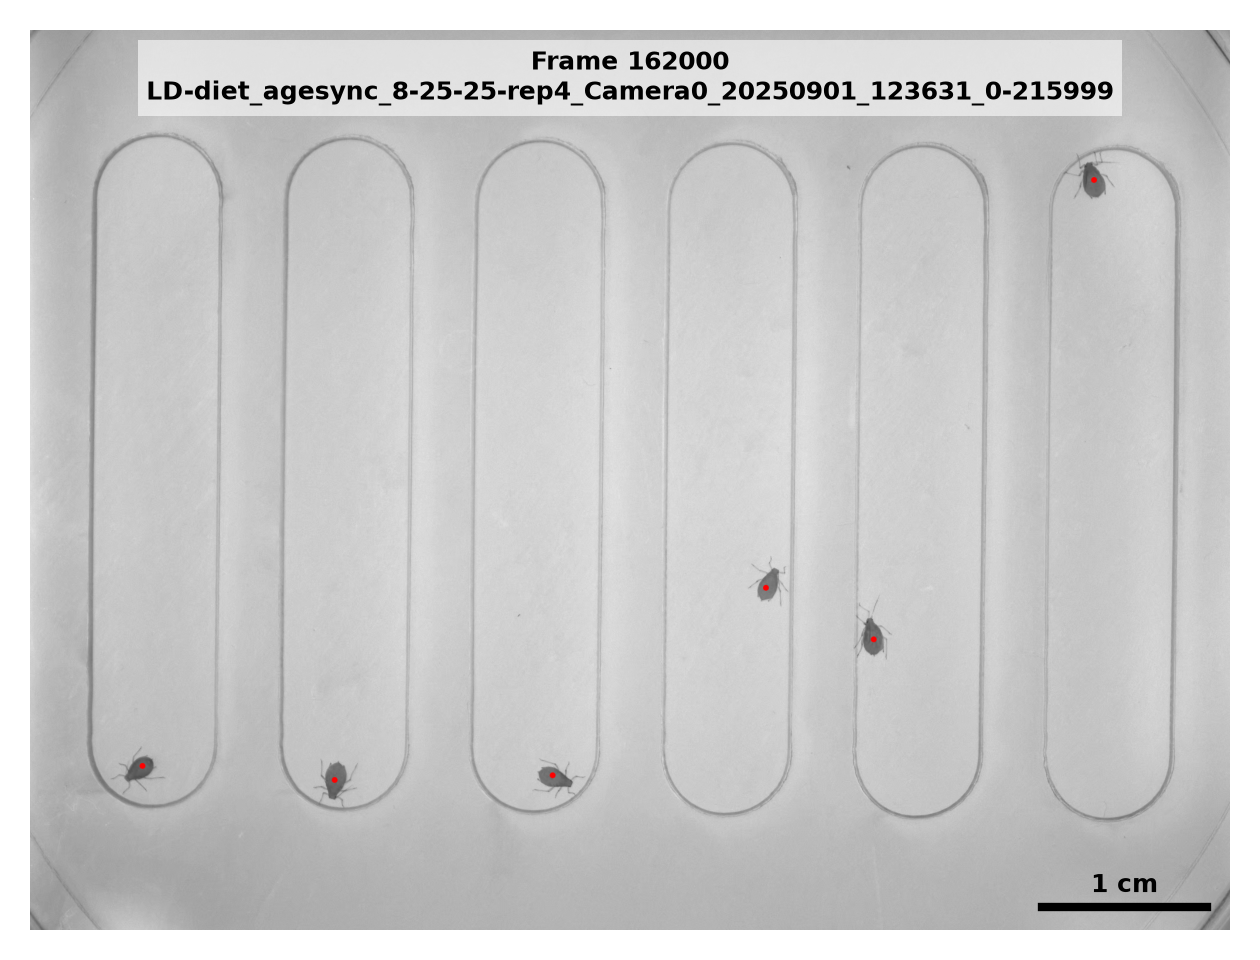

  Saved render -> output\single_frames\LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999_frame_162000_ab_only.png

Processing: LD-diet_agesync_8-25-25-rep4_Camera0_20250905_113649_20520000-20735999


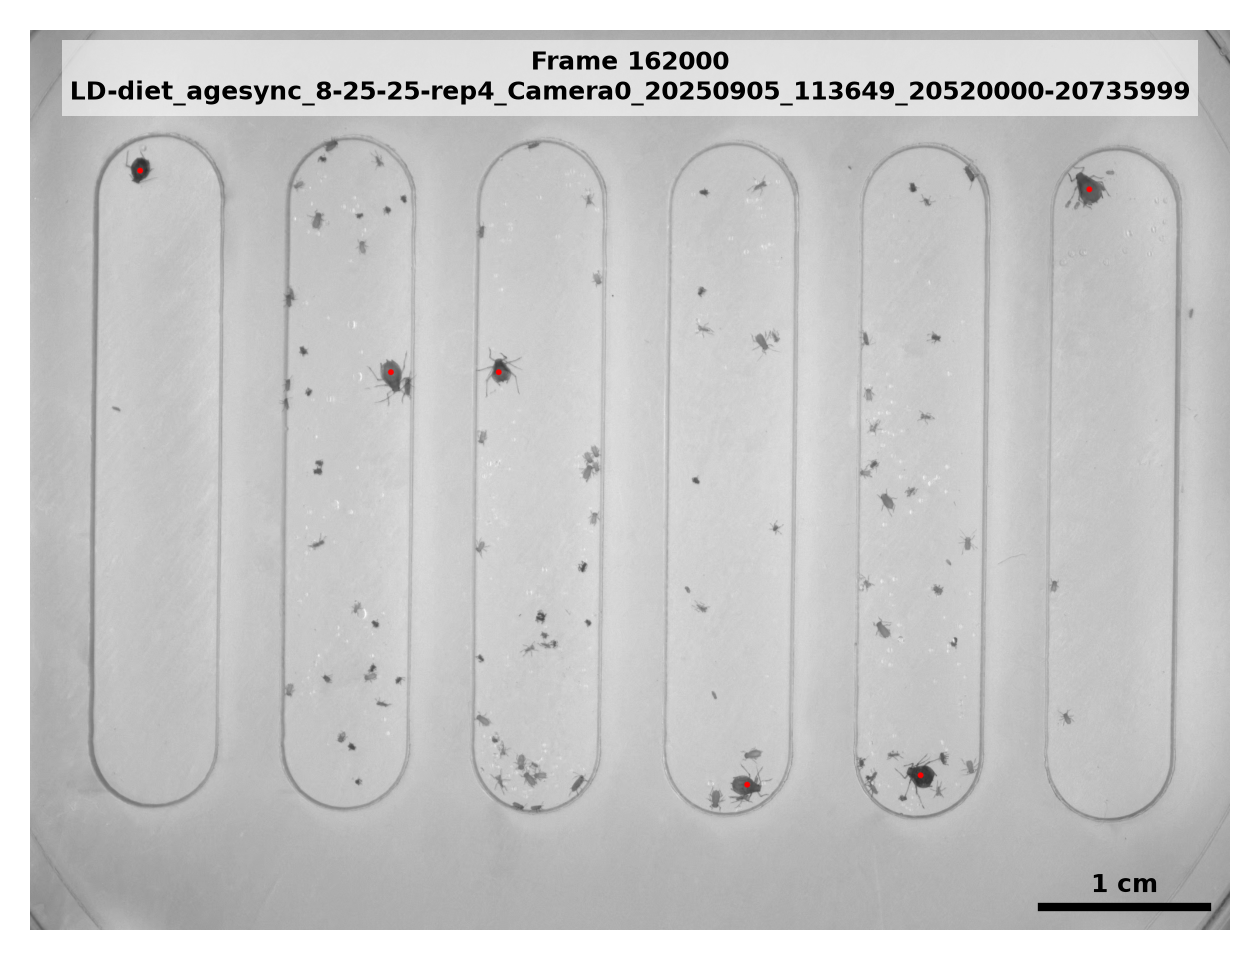

  Saved render -> output\single_frames\LD-diet_agesync_8-25-25-rep4_Camera0_20250905_113649_20520000-20735999_frame_162000_ab_only.png

Processing: DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999


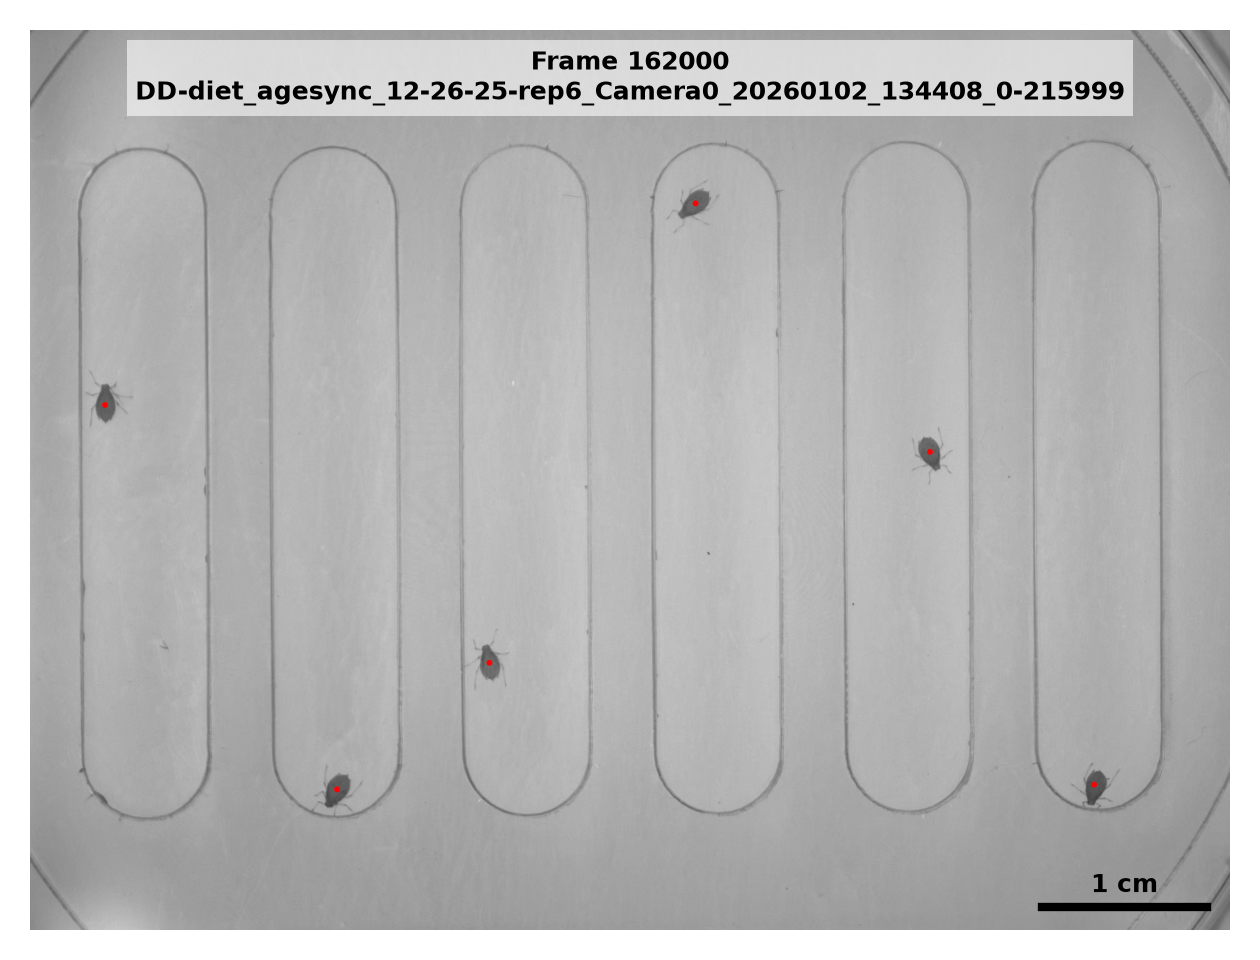

  Saved render -> output\single_frames\DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999_frame_162000_ab_only.png

Processing: DD-diet_agesync_12-26-25-rep6_Camera0_20260106_124429_20520000-20735999


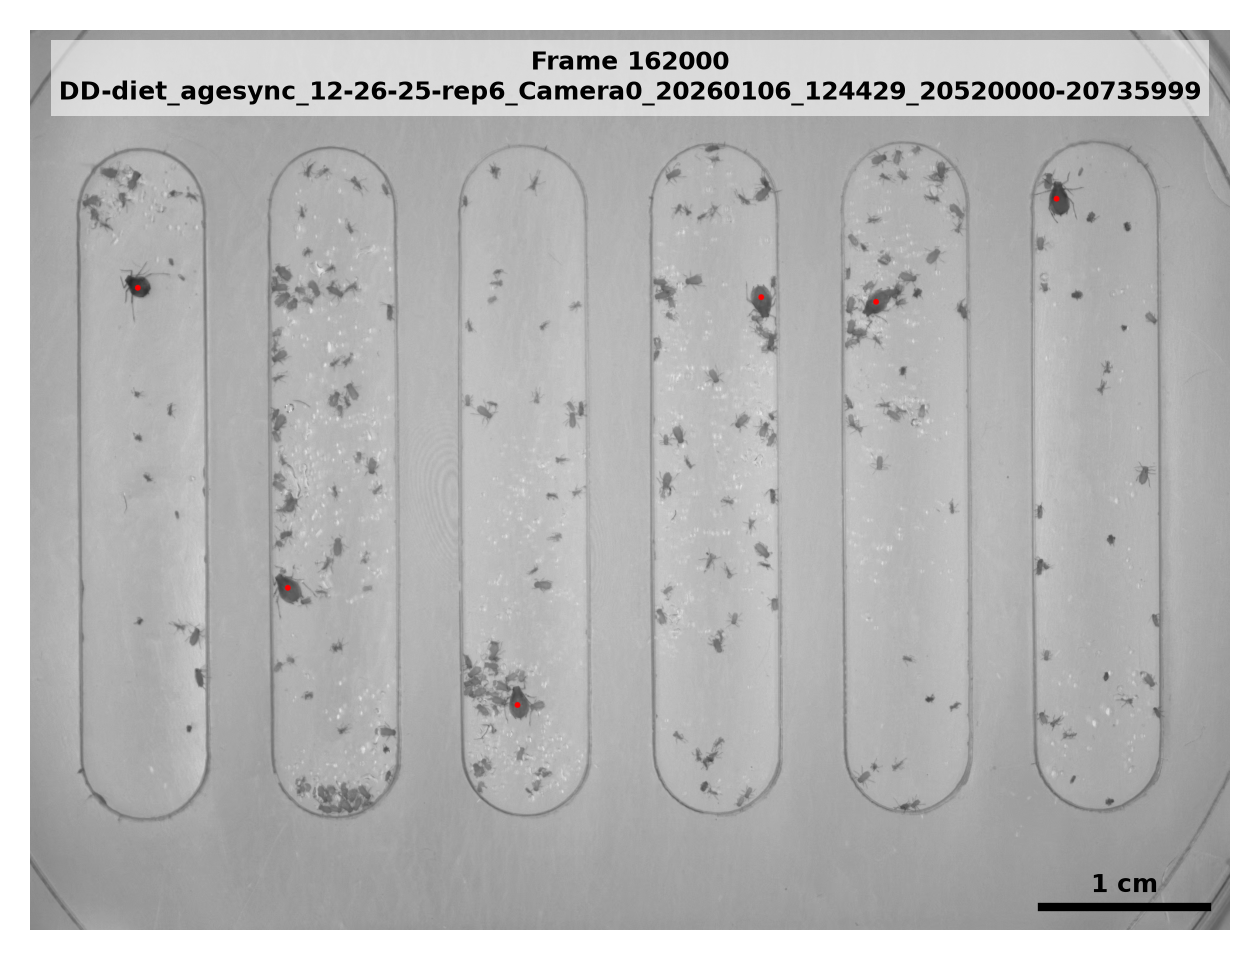

  Saved render -> output\single_frames\DD-diet_agesync_12-26-25-rep6_Camera0_20260106_124429_20520000-20735999_frame_162000_ab_only.png


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sleap_io as sio

# 1. Directories
VIDEO_DIR = Path("../videos")
PRED_DIR = Path("./")
OUT_DIR = Path("./output/single_frames")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. Target videos
TARGET_VIDEOS = [
    # Light-Dark (LD)
    "LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999.mp4",
    "LD-diet_agesync_8-25-25-rep4_Camera0_20250905_113649_20520000-20735999.mp4",
    # Constant Darkness (DD)
    "DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999.mp4",
    "DD-diet_agesync_12-26-25-rep6_Camera0_20260106_124429_20520000-20735999.mp4",
]

# 3. Settings 
FPS = 60
TARGET_MINUTE = 45
TARGET_FRAME_OFFSET = TARGET_MINUTE * 60 * FPS
TARGET_NODE = "ab"  # Target node to isolate

# 4. Render frames using native sleap_io rendering API
for video_name in TARGET_VIDEOS:
    stem = Path(video_name).stem
    video_path = VIDEO_DIR / video_name
    slp_path = PRED_DIR / f"{stem}_sleap.slp"

    if not slp_path.is_file():
        print(f"[ERROR] Missing SLP file: {slp_path.name}")
        continue
    if not video_path.is_file():
        print(f"[ERROR] Missing video file: {video_path.name}")
        continue

    print(f"\nProcessing: {stem}")
    labels = sio.load_slp(str(slp_path.resolve()))

    # Initialize a fresh video object to read frames reliably
    video = sio.Video.from_filename(str(video_path.resolve()))

    # Find the target LabeledFrame object (or closest frame <= TARGET_FRAME_OFFSET)
    target_lf = next(
        (lf for lf in labels.labeled_frames if lf.frame_idx == TARGET_FRAME_OFFSET),
        None,
    )

    if target_lf is None:
        valid_lfs = [
            lf for lf in labels.labeled_frames if lf.frame_idx <= TARGET_FRAME_OFFSET
        ]
        target_lf = (
            max(valid_lfs, key=lambda lf: lf.frame_idx)
            if valid_lfs
            else labels.labeled_frames[0]
        )
        print(
            f"  Exact frame {TARGET_FRAME_OFFSET} not indexed. Using closest labeled frame: {target_lf.frame_idx}"
        )

    # ------------------ ISOLATE ABDOMEN NODE ------------------
    skeleton = labels.skeletons[0]
    node_names = [n.name.lower() for n in skeleton.nodes]
    if TARGET_NODE.lower() in node_names:
        target_idx = node_names.index(TARGET_NODE.lower())
        mask = np.ones(len(skeleton.nodes), dtype=bool)
        mask[target_idx] = False  # Keep target node

        for inst in target_lf.instances:
            if hasattr(inst.points, "dtype") and inst.points.dtype.names:
                if "x" in inst.points.dtype.names:
                    inst.points["x"][mask] = np.nan
                if "y" in inst.points.dtype.names:
                    inst.points["y"][mask] = np.nan
                if "visible" in inst.points.dtype.names:
                    inst.points["visible"][mask] = False
            elif hasattr(inst.points, "shape"):
                inst.points[mask] = np.nan
    else:
        print(f"  [WARNING] Target node '{TARGET_NODE}' not found in skeleton.")
    # ----------------------------------------------------------

    # Manually extract the image frame and pass it directly to render_image
    frame_img = video[target_lf.frame_idx]
    if frame_img.ndim == 3 and frame_img.shape[-1] == 1:
        frame_img = frame_img.squeeze(-1)

    rendered_img = sio.render_image(
        target_lf,
        image=frame_img,
        color_by="node",
        palette="rainbow",
        show_nodes=True,
        show_edges=False,
        marker_size=5.0,  # Slightly larger for visibility since it's just one node
    )

    # Save and display without white borders
    out_img_path = OUT_DIR / f"{stem}_frame_{target_lf.frame_idx}_{TARGET_NODE}_only.png"
    
    # Dynamically scale height to match width of 4.0 inches based on frame aspect ratio
    h, w = frame_img.shape[:2]
    fig_width = 4.0 
    fig_height = fig_width * (h / w)
    
    # Use add_axes([0, 0, 1, 1]) to force the image to fill 100% of the figure
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.imshow(rendered_img)
    ax.axis("off")

    # ------------------ ON-IMAGE ANNOTATION ------------------
    condition = "LD" if "LD-" in video_name else "DD"
    annotation_text = f"Frame {target_lf.frame_idx}\n{stem}"
    
    ax.text(
        0.5, 0.98, 
        annotation_text, 
        transform=ax.transAxes, 
        color="black", 
        fontsize=6,  # Scaled down to fit smaller 4-inch wide figure
        fontweight="bold",
        ha="center", 
        va="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2.0)
    )
    # ---------------------------------------------------------

    # ------------------ SCALE BAR (1 cm) ---------------------
    px_per_cm = 281
    margin = 40  # pixels offset from the bottom right corner
    
    # Calculate pixel coordinates for the line
    x_end = w - margin
    x_start = x_end - px_per_cm
    y_pos = h - margin

    # Draw the line
    ax.plot([x_start, x_end], [y_pos, y_pos], color="black", linewidth=2)
    
    # Add the text label just above the line (subtracting y moves it "up" visually)
    ax.text(
        (x_start + x_end) / 2, 
        y_pos - 15,  
        "1 cm", 
        color="black", 
        fontsize=6,
        fontweight="bold",
        ha="center", 
        va="bottom"
    )
    # ---------------------------------------------------------

    # Add pad_inches=0 and remove tight_layout to kill the white border entirely
    plt.savefig(out_img_path, bbox_inches="tight", pad_inches=0, dpi=300)
    plt.show()
    plt.close()

    print(f"  Saved render -> {out_img_path}")